      Entity      Code  Year     emissions
36503  World  OWID_WRL  1850  4.216864e+09
36504  World  OWID_WRL  1851  4.314936e+09
36505  World  OWID_WRL  1852  4.381056e+09
36506  World  OWID_WRL  1853  4.459687e+09
36507  World  OWID_WRL  1854  4.547728e+09
...      ...       ...   ...           ...
36671  World  OWID_WRL  2018  5.282002e+10
36672  World  OWID_WRL  2019  5.345505e+10
36673  World  OWID_WRL  2020  5.145824e+10
36674  World  OWID_WRL  2021  5.344654e+10
36675  World  OWID_WRL  2022  5.385116e+10

[173 rows x 4 columns]
      emissions     average
1850   4.216864         NaN
1851   4.314936         NaN
1852   4.381056         NaN
1853   4.459687         NaN
1854   4.547728         NaN
...         ...         ...
2021  53.446540  414.703333
2022  53.851160  417.085000
2023  57.100000  419.354167
2024        NaN  422.787500
2025        NaN  426.030000

[176 rows x 2 columns]


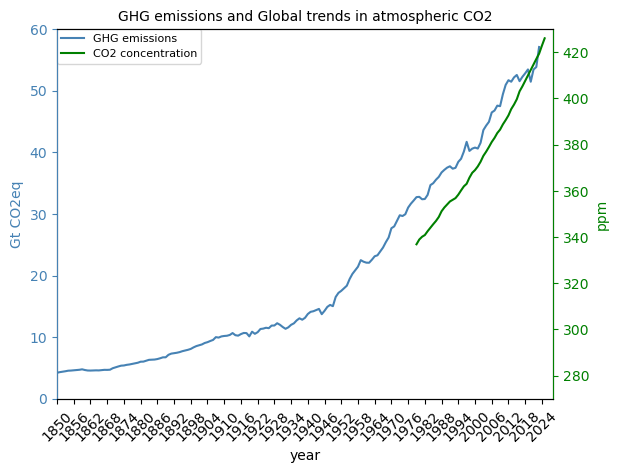

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/co2_mm_gl.csv')
co2_concentration = df.pivot_table('average', index='year')
#co2_concentration = co2_concentration[:-1]
#print(co2_concentration)
df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/total-ghg-emissions/total-ghg-emissions.csv')
#print(df)
#data = df.pivot_table('emissions', index='Year')
#ghg_emissions = df
data = df[df['Code'] == 'OWID_WRL']
print(data)
ghg = data.pivot_table('emissions', index='Year')/1000000000
plus = pd.DataFrame({'emissions':[57.1]}, index=[2023])

ghg_emissions = pd.concat([ghg, plus])
#print(ghg_emissions)
cumulative = ghg_emissions.cumsum()

#print(cumulative)


#print(ghg_emissions)
df = pd.merge(ghg_emissions, co2_concentration, left_index=True, right_index=True, how='outer')
df2 = pd.merge(cumulative, co2_concentration, left_index=True, right_index=True, how='inner')
print(df)
#print(df2)

x = range(1850, 2025+1)
#x1 = range(1850, 2025+1)

fig, ax1 = plt.subplots()
plt.title('GHG emissions and Global trends in atmospheric CO2', fontsize=10)
ax2 = ax1.twinx()
# 2軸グラフの本体設定
ax1.plot(x, df['emissions'], color='steelblue', label='GHG emissions')
ax2.plot(x, df['average'], color='green', label='CO2 concentration')

plt.tick_params(labelsize = 10)
handler1, label1 = ax1.get_legend_handles_labels()
handler2, label2 = ax2.get_legend_handles_labels()
ax1.legend(handler1 + handler2, label1 + label2, loc=2, fontsize=8, borderaxespad=0.)

ax1.set_xlim([1850, 2028])
plt.xticks(x[::6], fontsize=10)
ax1.xaxis.set_tick_params(rotation=45)
ax2.set_ylim([270, 430])
ax1.set_ylim([0, 60])
ax1.yaxis.label.set_color('steelblue')
ax2.yaxis.label.set_color('green')
# 目盛りの色
ax1.tick_params(axis='y', colors='steelblue')
ax2.tick_params(axis='y', colors='green')

ax2.spines['left'].set_color('steelblue')
ax2.spines['right'].set_color('green')
# 

#x_label = np.array(df['year'])
ax1.set_xlabel('year', fontsize=10)
ax2.set_ylabel('ppm', color='green', fontsize=10)
ax1.set_ylabel('Gt CO2eq', color='steelblue', fontsize=10)
plt.show()

In [2]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_json('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/era5_world_t2_day.json')
df3 = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/co2_mm_gl.csv')
co2_concentration = df3.pivot_table('average', index='year')
#co2_concentration = co2_concentration[:-1]
#print(co2_concentration)

df4 = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/cumulative-co-emissions/cumulative-co-emissions.csv')
#print(df4)

temp = []
for i in range(len(df)-3):
    yr = int(df['name'][i])
    y = df['data'][i]
    #print(y)
    new_y = [x for x in y if x is not None]
    # マスクを適用してnanを無視した計算を行う
    #print(new_y)
    #print(i)
    temp.append(np.mean(new_y))

temperature = pd.DataFrame(temp, index=range(1940, 2025+1))
temperature.columns = ['temperature (°C)']
#print(temperature)
TEMP = temperature.iloc[1979-1940:2023-1940+1]
#print(TEMP)
#print(df2)

df5 = df4[df4['Year'] >= 1979]
cumulative = df5.pivot_table('Cumulative CO₂ emissions', index='Year')/1000000000

print(cumulative.tail(20))
df2 = pd.merge(cumulative, co2_concentration, left_index=True, right_index=True, how='inner')

df2.columns = [ 'cumulative CO2 emissions (Gt)','CO2 concentration (ppm)']

catg = [40, 100, 140, 200, 240, 360]
catg2 = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

count = 0
ctg = []
for i in range(1979, 2023+1):
    #c = catg[count]
    if i <= 1979:
        ctg.append(catg[0])
    elif 1980 <= i <= 1989:
        ctg.append(catg[1])
    elif 1990 <= i <= 1999:
        ctg.append(catg[2])
    elif 2000 <= i <= 2009:
        ctg.append(catg[3])
    elif 2010 <= i <= 2019:
        ctg.append(catg[4])
    elif 2020 <= i:
        ctg.append(catg[5])    
#print(ctg)

category = pd.DataFrame(ctg, index=range(1979, 2023+1))
#print(category)
category.columns = ['category']

data1 = pd.merge(df2, TEMP, left_index=True, right_index=True)
data = pd.merge(data1, category, left_index=True, right_index=True)

data1.to_csv('/Users/kurozuhajime/Desktop/test.csv')

#print(data)
#print(data['temperature (°C)'])
#sns.set(rc={"axes.facecolor": "black", "figure.facecolor":'k', "axes.labelcolor":'w', "legend.labelcolor":'w'})
#sns.set_theme(style="white")
#sns.pairplot(data, hue='category', palette='Blues')


Pre_Indst_Temp = 13.495379371584699


      Cumulative CO₂ emissions
Year                          
2004                 1155.5007
2005                 1185.1151
2006                 1215.7435
2007                 1247.2781
2008                 1279.3524
2009                 1310.8943
2010                 1344.2502
2011                 1378.7548
2012                 1413.7548
2013                 1449.0564
2014                 1484.5065
2015                 1519.9114
2016                 1555.3280
2017                 1591.3179
2018                 1628.0483
2019                 1665.1526
2020                 1700.2792
2021                 1737.2709
2022                 1774.5647
2023                 1812.3563


45
a=0.0007160659630063302, b=13.509633627921382
CO2 emission at 15°C(+1.5°C) = 2074.873
[[1.         0.93720985]
 [0.93720985 1.        ]]
46
46


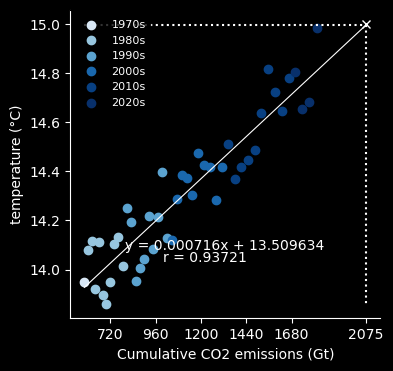

In [3]:
# Graph 1 --------------------------------------------------

#X = data['GHG cumulative emissions (Gt)']
X = data['cumulative CO2 emissions (Gt)']
Y = data['temperature (°C)']
print(len(data))

yy = Y.to_numpy()
xx = X.to_numpy()


a, b = np.polyfit(X, Y, 1)

print(f'a={a}, b={b}')


#GHG_at_15 = round((Pre_Indst_Temp+1.5-b)/a, 3)
#print(f'GHG emission at 15°C(+1.5°C) = {GHG_at_15}')

CO2_at_15 = round((Pre_Indst_Temp+1.5-b)/a, 3)
print(f'CO2 emission at 15°C(+1.5°C) = {CO2_at_15}')


y = np.append(yy, 15)
x = np.append(xx, CO2_at_15)


# フィッティング直線
y2 = a * x + b

p = np.corrcoef(x, y)
print(p)
cr = p[0][1]


"""
#print(len(y))

yy = Y.to_numpy()
xx = x.to_numpy()

y = np.append(yy, 15.0)
#x = np.append(xx, GHG_at_15)
x = np.append(xx, CO2_at_15)

a, b = np.polyfit(x, y, 1)

print(f'a={a}, b={b}')
# フィッティング直線
y2 = a * x + b

p = np.corrcoef(x, y)
#print(p)
cr = p[0][1]

"""

fig = plt.figure(figsize=(4.0, 4.0), facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

for i in range(len(data)+1):
    #plt.plot(x.iloc[i], y.iloc[i], marker='o', color=cm.Blues(data['category'].iloc[i]))
    if i < len(data):
        plt.plot(x[i], y[i], marker='o', color=cm.Blues(data['category'].iloc[i]))
    else:
        plt.plot(x[i], y[i], marker='x', color='w')

#plt.plot([x.min(),GHG_at_15], [Pre_Indst_Temp+1.5, Pre_Indst_Temp+1.5], color='w', linestyle=':')
#plt.plot([GHG_at_15,GHG_at_15], [Pre_Indst_Temp+1.5, y.min()], color='w', linestyle=':')

plt.plot([x.min(),CO2_at_15], [Pre_Indst_Temp+1.5, Pre_Indst_Temp+1.5], color='w', linestyle=':')
plt.plot([CO2_at_15,CO2_at_15], [Pre_Indst_Temp+1.5, y.min()], color='w', linestyle=':')


for i in range(len(catg)):
    plt.scatter([],[],marker='o', color=cm.Blues(catg[i]),label=catg2[i])

print(len(x))
print(len(y2))
plt.plot(x, y2, linewidth=0.8, color='w')

#plt.text(2000,a*2000+b, 'y = '+ str(round(a,6)) +'x + '+str(round(b,6)), fontsize=10, color='w')
#plt.text(2400,a*1860+b, 'r = '+str(round(cr,6)), fontsize=10,  color='w')
plt.text(800,a*800+b, 'y = '+ str(round(a,6)) +'x + '+str(round(b,6)), fontsize=10, color='w')
plt.text(1000,a*730+b, 'r = '+str(round(cr,6)), fontsize=10,  color='w')


#plt.xlabel('GHG cumulative emissions (Gt)')
plt.xlabel('Cumulative CO2 emissions (Gt)')
plt.ylabel('temperature (°C)')
#plt.xticks([1500, 2000, 2500, 3000, 3500, GHG_at_15])
plt.xticks([720, 960, 1200, 1440, 1680, CO2_at_15])
plt.yticks([14.0, 14.2, 14.4, 14.6, 14.8, round(Pre_Indst_Temp+1.5, 2)])
plt.legend(labelcolor="w",facecolor='k', edgecolor='k',framealpha=0.8, loc='upper left', fontsize=8)

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.show()


a=0.010758055424320474, b=10.290881072041856
CO2 concentration at 15°C(+1.5°C) = 437.3
[[1.         0.93868645]
 [0.93868645 1.        ]]


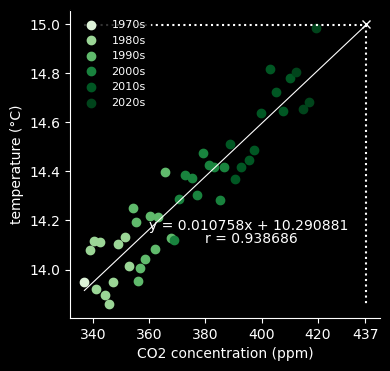

In [4]:

# Graph 2 --------------------------------------------------

X = data['CO2 concentration (ppm)']
Y = data['temperature (°C)']

yy = Y.to_numpy()
xx = X.to_numpy()

a, b = np.polyfit(X, Y, 1)

print(f'a={a}, b={b}')

CO2con_at_15 = round((Pre_Indst_Temp+1.5-b)/a, 3)
print(f'CO2 concentration at 15°C(+1.5°C) = {CO2con_at_15}')


y = np.append(yy, 15)
x = np.append(xx, CO2con_at_15)


# フィッティング直線
y2 = a * x + b

p = np.corrcoef(x, y)
print(p)
cr = p[0][1]


fig = plt.figure(figsize=(4.0, 4.0), facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

for i in range(len(data)+1):
    #plt.plot(x.iloc[i], y.iloc[i], marker='o', color=cm.Greens(data['category'].iloc[i]))
    if i < len(data):
        plt.plot(x[i], y[i], marker='o', color=cm.Greens(data['category'].iloc[i]))
    else:
        plt.plot(x[i], y[i], marker='x', color='w')



for i in range(len(catg)):
    plt.scatter([],[],marker='o', color=cm.Greens(catg[i]),label=catg2[i])
plt.plot(x, y2, linewidth=0.8, color='w')

plt.plot([x.min(),CO2con_at_15], [Pre_Indst_Temp+1.5, Pre_Indst_Temp+1.5], color='w', linestyle=':')
plt.plot([CO2con_at_15,CO2con_at_15], [Pre_Indst_Temp+1.5, y.min()], color='w', linestyle=':')



plt.text(360,a*360+b, 'y = '+ str(round(a,6)) +'x + '+str(round(b,6)), fontsize=10, color='w')
plt.text(380,a*355+b, 'r = '+str(round(cr,6)), fontsize=10,  color='w')
plt.xlabel('CO2 concentration (ppm)')
plt.ylabel('temperature (°C)')

plt.xticks([340, 360, 380, 400, 420, round(CO2con_at_15)])
plt.yticks([14.0, 14.2, 14.4, 14.6, 14.8, round(Pre_Indst_Temp+1.5, 2)])

plt.legend(labelcolor="w",facecolor='k', edgecolor='k',framealpha=0.8, loc='upper left', fontsize=8)

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.show()

[[1.         0.99971876]
 [0.99971876 1.        ]]


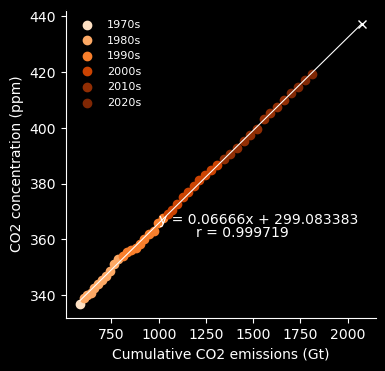

      cumulative CO2 emissions (Gt)  CO2 concentration (ppm)  \
2014                      1484.5065               397.344167   
2015                      1519.9114               399.649167   
2016                      1555.3280               403.088333   
2017                      1591.3179               405.216667   
2018                      1628.0483               407.612500   
2019                      1665.1526               410.071667   
2020                      1700.2792               412.443333   
2021                      1737.2709               414.703333   
2022                      1774.5647               417.085000   
2023                      1812.3563               419.354167   

      temperature (°C)  category  
2014         14.487000       240  
2015         14.636573       240  
2016         14.814230       240  
2017         14.723364       240  
2018         14.644047       240  
2019         14.779233       240  
2020         14.805363       360  
2021         14

In [5]:


# Graph 3 --------------------------------------------------

Y = data['CO2 concentration (ppm)']
X = data['cumulative CO2 emissions (Gt)']
#X = data['GHG cumulative emissions (Gt)']
#print(len(y))

yy = Y.to_numpy()
xx = X.to_numpy()

y = np.append(yy, CO2con_at_15)
#x = np.append(xx, GHG_at_15)
x = np.append(xx, CO2_at_15)

#print(x)
#print(y)


a, b = np.polyfit(X, Y, 1)
# フィッティング直線
y2 = a * x + b

p = np.corrcoef(x, y)
print(p)
cr = p[0][1]





fig = plt.figure(figsize=(4.0, 4.0), facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

for i in range(len(data)+1):
    #plt.plot(x.iloc[i], y.iloc[i], marker='o', color=cm.Oranges(data['category'].iloc[i]))
    if i < len(data):
        plt.plot(x[i], y[i], marker='o', color=cm.Oranges(data['category'].iloc[i]))
    else:
        plt.plot(x[i], y[i], marker='x', color='w')
        
for i in range(len(catg)):
    plt.scatter([],[],marker='o', color=cm.Oranges(catg[i]),label=catg2[i])
plt.plot(x, y2, linewidth=0.8, color='w')
#plt.text(2000,a*2000+b, 'y = '+ str(round(a,6)) +'x + '+str(round(b,6)), fontsize=10, color='w')
#plt.text(2400,a*1860+b, 'r = '+str(round(cr,6)), fontsize=10,  color='w')

plt.text(1000,a*1000+b, 'y = '+ str(round(a,6)) +'x + '+str(round(b,6)), fontsize=10, color='w')
plt.text(1200,a*930+b, 'r = '+str(round(cr,6)), fontsize=10,  color='w')

plt.ylabel('CO2 concentration (ppm)')
plt.xlabel('Cumulative CO2 emissions (Gt)')
#plt.xlabel('GHG cumulative emissions (Gt)')
#plt.xticks([720, 960, 1200, 1440, 1680, CO2_at_15])
plt.legend(labelcolor="w",facecolor='k', edgecolor='k',framealpha=0.8, loc='upper left', fontsize=8)

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.show()
#print(y.iloc[len(y)-1])
print(data.tail(10))

#x = df2['emissions']
#print(df2)
#y = df2['average']
#z = temp[39:]
#r = np.corrcoef(x, y)
#a, b = np.polyfit(x, y, 1)
#plt.scatter(x, y)
#plt.plot(x, a*x+b, color='darkred')
#print(r)
#plt.show()

1812.3563


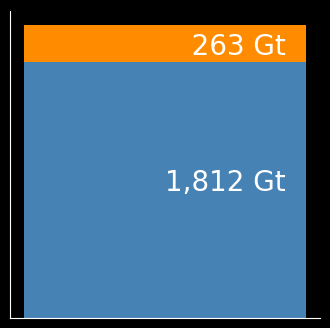

In [6]:
#GHG_2023 = X.iloc[len(X)-1]
#print(GHG_2023)
CO2_2023 = X.iloc[len(X)-1]
print(CO2_2023)


fig = plt.figure(figsize=(4.0, 4.0), facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

#plt.bar(1, GHG_2023, color="steelblue")
#plt.bar(1, GHG_at_15-GHG_2023, bottom=GHG_2023, color="darkorange")

plt.bar(1, CO2_2023, color="steelblue")
plt.bar(1, CO2_at_15-CO2_2023, bottom=CO2_2023, color="darkorange")


plt.xticks([])
plt.yticks([])

#plt.text(1,3600, f'{round(GHG_at_15-GHG_2023):6d} Gt', fontsize=20, color='w')
#plt.text(1,1800,  f'{round(GHG_2023):,} Gt', fontsize=20,  color='w')

plt.text(1,1860, f'{round(CO2_at_15-CO2_2023):6d} Gt', fontsize=20, color='w')
plt.text(1,900,  f'{round(CO2_2023):,} Gt', fontsize=20,  color='w')



ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

"""
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
"""

plt.show()


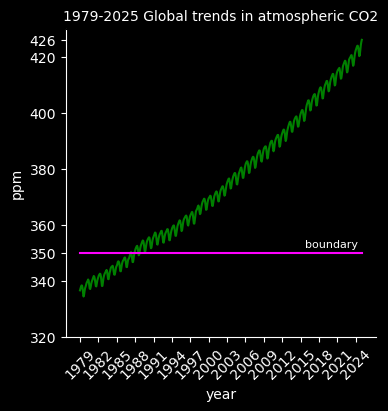

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/co2_mm_gl.csv')
#co2_concentration = df.pivot_table('average', index='year')
#co2_concentration = df
#print(co2_concentration)

mnth = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 

this_year = 2025
x = range(len(df))

ss = []
for i in range(len(df)):
    s = str(mnth[df['month'][i]-1]) + '/' + str(df['year'][i]) 
    
    ss.append(s)


fig = plt.figure(figsize=(4.0, 4.0), facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

style = dict(size=8, color='w')

#print(ss)
plt.title(f'1979-{this_year} Global trends in atmospheric CO2', color='w', fontsize=10)
plt.subplot()
plt.plot(x, df['average'], color='green')
plt.ylim(320,430)
plt.xlabel('year', color='w')
plt.ylabel('ppm', color='w')
plt.xticks(x[::36], df['year'][::36], fontsize=10)
plt.yticks([320,340, 350, 360, 380, 400,420, df['average'].iloc[-1]])
boundary = np.full(len(x), 350)
plt.plot(x, boundary, color='magenta')
plt.text(x[440], 352, f'boundary', **style)


ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w',labelrotation=45)
ax.tick_params(axis='y', colors='w')

plt.show()


Text(0, 0.5, 'ppb')

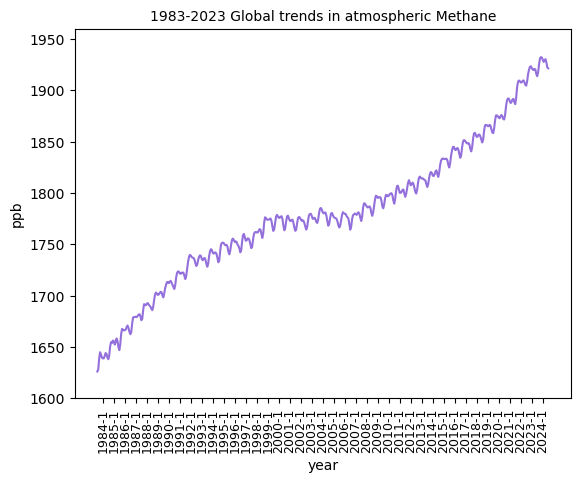

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/ch4_mm_gl.csv')
#ch4_concentration = df.pivot_table('average', index='year')
ch4_concentration = df
#print(ch4_concentration)
#x = range(1983, 2023+1)

ss = []
for i in range(len(df)):
    s = str(df['year'][i]) + '-' + str(df['month'][i])
    ss.append(s)

x = range(len(df))
fig = plt.subplot()
plt.title('1983-2023 Global trends in atmospheric Methane', fontsize=10)
plt.plot(x, ch4_concentration['average'], color='mediumpurple')
#plt.xlim([1983, 2024])
plt.ylim([1600, 1960])
plt.xticks(x[6::12], ss[6::12], fontsize=9, rotation=90)
plt.xlabel('year', fontsize=10)
plt.ylabel('ppb', color='k', fontsize=10)


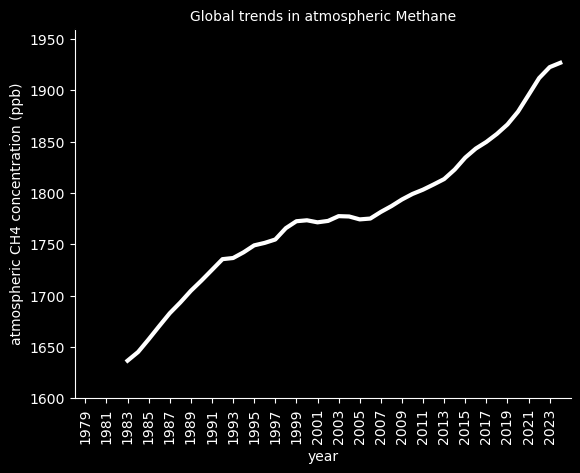

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/ch4_mm_gl.csv')
ch4_concentration = df.pivot_table('average', index='year')
#ch4_concentration = df
#print(ch4_concentration)
x = range(1983, 2024+1)
x1 = range(1979, 2025)
y = ch4_concentration['average']
#z = by_year - mean_temp_all

#print(z)

plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

fig = plt.subplot()

plt.title('Global trends in atmospheric Methane', color='w', fontsize=10)


"""
plt.title('Global trends in atmospheric N2O and Temperature anomaly (1979-2000 base)', color='w', fontsize=10)

for i in range(1979, 2024):
    if z[i] > 0.0:
        plt.bar(i, 430, alpha=.7, width=1, color=cm.Reds(2*(z[i])-0.2), edgecolor='white')
    else:
        plt.bar(i, 430, alpha=.7, width=1, color=cm.Blues(-2*(z[i])+0.2), edgecolor='white')

#for i in range(1979, 2024):
#    plt.bar(i, 430, alpha=.7, width=1, color=cm.jet(2*(z[i])-0.2), edgecolor='white')

"""

plt.plot(x, y, color='w', linewidth=3, label='atmospheric CH4')

"""

ln1 = [0.6, 0.4, 0.3, 0.2, 0.1]
ln2 = [0, -0.1, -0.2]


for i in ln1:
    if i == 0.6:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i))
for i in ln2:
    if i == -0.2:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i))
"""

"""

for i in ln1:
    if i == '0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i)
for i in ln2:
    if i == '-0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i)

"""

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.ylim([1600, 1960])
plt.xlim(1978, 2025)
plt.xticks(x1[::2], color='w', fontsize=10, rotation=90)
plt.xlabel('year', color='w', fontsize=10)
plt.ylabel('atmospheric CH4 concentration (ppb)', color='w', fontsize=10)
#plt.legend(fontsize=7, facecolor='gray', framealpha=0.8, loc='upper left')
#plt.colorbar()
plt.show()


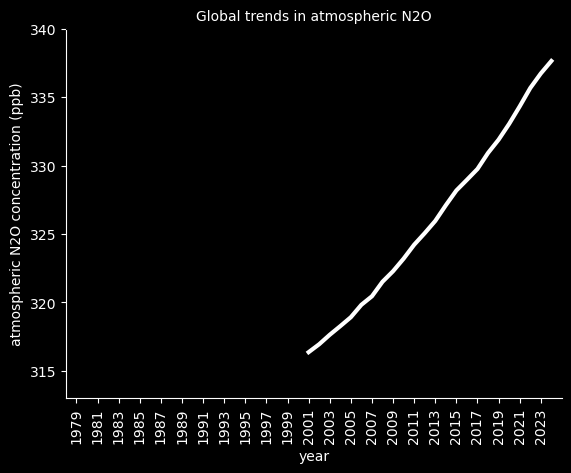

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/n2o_mm_gl.csv')
n2o_concentration = df.pivot_table('average', index='year')
#ch4_concentration = df
#print(ch4_concentration)
x = range(2001, 2024+1)
x1 = range(1979, 2025)
y = n2o_concentration['average']
#z = by_year - mean_temp_all

#print(z)

plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

fig = plt.subplot()

plt.title('Global trends in atmospheric N2O', color='w', fontsize=10)

"""
plt.title('Global trends in atmospheric N2O and Temperature anomaly (1979-2000 base)', color='w', fontsize=10)

for i in range(1979, 2024):
    if z[i] > 0.0:
        plt.bar(i, 340, alpha=.7, width=1, color=cm.Reds(2*(z[i])-0.2), edgecolor='white')
    else:
        plt.bar(i, 340, alpha=.7, width=1, color=cm.Blues(-2*(z[i])+0.2), edgecolor='white')

#for i in range(1979, 2024):
#    plt.bar(i, 430, alpha=.7, width=1, color=cm.jet(2*(z[i])-0.2), edgecolor='white')

"""

plt.plot(x, y, color='w', linewidth=3, label='atmospheric N2O')

"""

ln1 = [0.6, 0.4, 0.3, 0.2, 0.1]
ln2 = [0, -0.1, -0.2]


for i in ln1:
    if i == 0.6:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i))
for i in ln2:
    if i == -0.2:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i))
"""

"""

for i in ln1:
    if i == '0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i)
for i in ln2:
    if i == '-0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i)

"""

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.ylim([313, 340])
plt.xlim(1978, 2025)
plt.xticks(x1[::2], color='w', fontsize=10, rotation=90)
plt.xlabel('year', color='w', fontsize=10)
plt.ylabel('atmospheric N2O concentration (ppb)', color='w', fontsize=10)
#plt.legend(fontsize=7, facecolor='gray', framealpha=0.8, loc='upper left')
#plt.colorbar()
plt.show()


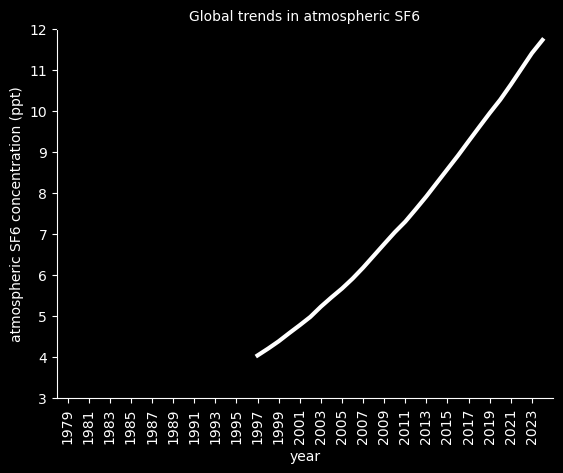

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/sf6_mm_gl.csv')
sf6_concentration = df.pivot_table('average', index='year')
#ch4_concentration = df
#print(ch4_concentration)
x1 = range(1979, 2025)
x = range(1997, 2025)
y = sf6_concentration['average']
#z = by_year - mean_temp_all

#print(z)

plt.figure(facecolor='k')
ax = plt.axes()
ax.set_facecolor('k')

fig = plt.subplot()

plt.title('Global trends in atmospheric SF6', color='w', fontsize=10)

"""

plt.title('Global trends in atmospheric SF6 and Temperature anomaly (1979-2000 base)', color='w', fontsize=10)

for i in range(1979, 2024):
    if z[i] > 0.0:
        plt.bar(i, 12, alpha=.7, width=1, color=cm.Reds(2*(z[i])-0.2), edgecolor='white')
    else:
        plt.bar(i, 12, alpha=.7, width=1, color=cm.Blues(-2*(z[i])+0.2), edgecolor='white')

#for i in range(1979, 2024):
#    plt.bar(i, 430, alpha=.7, width=1, color=cm.jet(2*(z[i])-0.2), edgecolor='white')

"""

plt.plot(x, y, color='w', linewidth=3, label='atmospheric SF6')

"""
ln1 = [0.6, 0.4, 0.3, 0.2, 0.1]
ln2 = [0, -0.1, -0.2]

for i in ln1:
    if i == 0.6:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Reds(2*i-0.2), label='+'+str(i))
for i in ln2:
    if i == -0.2:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i)+'~')
    else:
        plt.plot([],[], alpha=.7, linewidth=3, color=cm.Blues(-2*i+0.2), label=str(i))
"""

"""        
for i in ln1:
    if i == '0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label='+'+i)
for i in ln2:
    if i == '-0.6':
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i+'~')
    else:
        plt.plot([],[], color=cm.jet(2*float(i)-0.2), label=i)

"""

ax.spines['left'].set_color('w')
ax.spines['bottom'].set_color('w')
# ラベルの色
ax.xaxis.label.set_color('w')
ax.yaxis.label.set_color('w')
# 目盛りの色
ax.tick_params(axis='x', colors='w')
ax.tick_params(axis='y', colors='w')

plt.ylim([3, 12])
plt.xlim(1978, 2025)
plt.xticks(x1[::2], color='w', fontsize=10, rotation=90)
plt.xlabel('year', color='w', fontsize=10)
plt.ylabel('atmospheric SF6 concentration (ppt)', color='w', fontsize=10)
#plt.legend(fontsize=7, facecolor='gray', framealpha=0.8, loc='upper left')
#plt.colorbar()
plt.show()
